# 404 — Diagrama del diseño experimental (Corrección C \#19)

Produce dos figuras para la sección §3.1 de la tesis:

- **Figura A:** distribución espacial real de los tratamientos en campo (335 polígonos coloreados por nivel de P), derivada de `data/raw/labels_export.gpkg`.
- **Figura B:** diagrama factorial conceptual — 8 genotipos × 4 niveles de P × 3 repeticiones.

**Paleta de colores:** idéntica al notebook 103 (`#FFD966`, `#F8CBAD`, `#B4C6E7`, `#FFFFFF` para clases 0–3).

**Nota sobre reconstrucción de grilla:** el campo `plot` del GeoPackage es un identificador de unidad experimental, no una posición física. Los centroides por surco convergen en un radio de ~8 m porque cada surco agrupa plantas de los 4 niveles de P repartidas por todo el campo. La grilla 6×16 del Anexo 32 no se puede reconstruir automáticamente desde esta columna. Se grafica la distribución real de polígonos, que revela la estructura espacial del experimento: los niveles de P se organizan en **bandas horizontales** (Sur = T4 control, Norte = T1 estrés severo).

## Librerías

In [30]:
import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from spectralcrop.utils.path_manager import PathManager


PM = PathManager()

def _resolve(path):
    if isinstance(path, list):
        return [p for p in path if 'spectralcrop' not in p][0]
    return path

REPORTS_PATH   = _resolve(PM.get_abs_path_folder('reports'))
FIGS_PATH = REPORTS_PATH / Path("figures/experimental_design")
FIGS_PATH.mkdir(parents=True, exist_ok=True)

print(FIGS_PATH)

c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\experimental_design


## 1. Paleta de colores y metadatos

In [32]:
# Mismos colores que notebook 103 (overlay labels_multiclass)
CLASS_COLORS = {
    0: "#FFD966",   # T4 100% P — amarillo  (control, no estresado)
    1: "#F8CBAD",   # T3  75% P — durazno   (estrés leve)
    2: "#B4C6E7",   # T2  50% P — azul      (estrés moderado)
    3: "#FFFFFF",   # T1  25% P — blanco     (estrés severo)
}
CLASS_LABELS = {
    0: "T4 – 100% P (no estresado)",
    1: "T3 – 75% P (estrés leve)",
    2: "T2 – 50% P (estrés moderado)",
    3: "T1 – 25% P (estrés severo)",
}
GENOTYPE_NAMES = {
    1: "L1-12702",   2: "L2-G11819", 3: "L3-G50834", 4: "L4-50840",
    5: "L15-51433",  6: "L17-G51018", 7: "Liborino",  8: "Cargamanto",
}
print("Paleta configurada (coherente con notebook 103)")


Paleta configurada (coherente con notebook 103)


## 2. Carga de datos y verificación espacial

In [33]:
RAW_DATA_PATH = PM.get_abs_path_folder("raw")

gdf = gpd.read_file(RAW_DATA_PATH + "labels_export.gpkg", layer="labels2")
cx_arr = gdf.geometry.centroid.x.values
cy_arr = gdf.geometry.centroid.y.values
gdf = gdf.copy()
gdf["cx"] = cx_arr
gdf["cy"] = cy_arr

print(f"Polígonos cargados : {len(gdf)}")
print(f"Surcos (plot)      : {sorted(gdf['plot'].unique())}")
print(f"Entries            : {sorted(gdf['entry'].unique())}")
print(f"Reps               : {sorted(gdf['rep'].unique())}")
print(f"Classes            : {sorted(gdf['class'].unique())}")
print(f"CRS                : {gdf.crs}")
print(f"Span X             : {cx_arr.max()-cx_arr.min():.1f} m")
print(f"Span Y             : {cy_arr.max()-cy_arr.min():.1f} m")

# Verificar estructura por bandas Y
q = pd.qcut(gdf["cy"], q=4, labels=["Sur (Q1)", "SC (Q2)", "NC (Q3)", "Norte (Q4)"])
ct = pd.crosstab(q, gdf["class"]).rename(
    columns={0: "T4 (100%)", 1: "T3 (75%)", 2: "T2 (50%)", 3: "T1 (25%)"}
)
print("\nDistribución de nivel P por cuartil Norte-Sur:")
print(ct)
print("\nConclusión: los niveles de P se distribuyen en bandas horizontales (Sur→Norte).")


Polígonos cargados : 335
Surcos (plot)      : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24)]
Entries            : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]
Reps               : [np.int32(1), np.int32(2), np.int32(3)]
Classes            : [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
CRS                : EPSG:32618
Span X             : 49.4 m
Span Y             : 56.1 m

Distribución de nivel P por cuartil Norte-Sur:
class       T4 (100%)  T3 (75%)  T2 (50%)  T1 (25%)
cy                                                 
Sur (Q1)           56        28         0         0
SC (Q2)            25        47         0     

## 3. Figura A — Distribución espacial real de tratamientos

Mapa de puntos derivado de la geometría del GeoPackage. Cada punto es el centroide de un polígono de planta, coloreado por nivel de P.

c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\experimental_design\distribucion_espacial_tratamientos.png


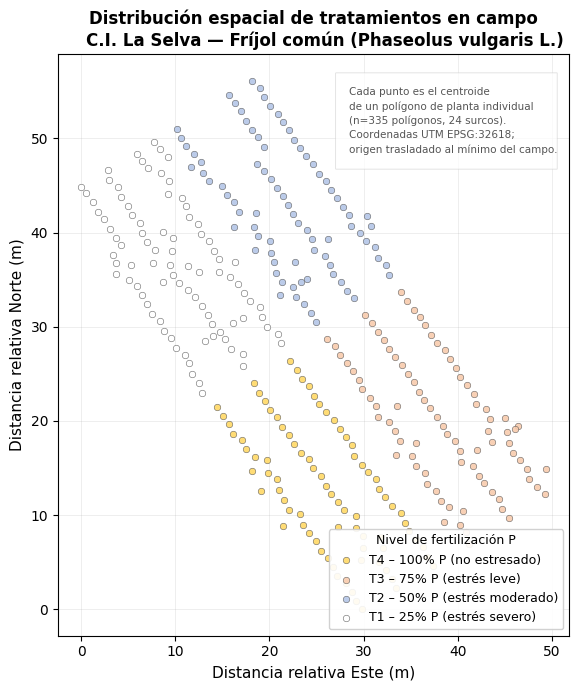

Figura A guardada.


In [34]:
fig_a, ax = plt.subplots(figsize=(11, 7))

for cls in sorted(CLASS_COLORS):
    mask = gdf["class"] == cls
    ax.scatter(
        gdf.loc[mask, "cx"] - cx_arr.min(),
        gdf.loc[mask, "cy"] - cy_arr.min(),
        c=CLASS_COLORS[cls],
        s=22, alpha=0.90, linewidths=0.4,
        edgecolors="#555555",
        label=CLASS_LABELS[cls],
        zorder=3,
    )
    
ax.set_xlabel("Distancia relativa Este (m)", fontsize=11)
ax.set_ylabel("Distancia relativa Norte (m)", fontsize=11)
ax.set_title(
    """Distribución espacial de tratamientos en campo
    C.I. La Selva — Fríjol común (Phaseolus vulgaris L.)""",
    fontsize=12, fontweight="bold",
)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3, linewidth=0.5)

x_span = cx_arr.max() - cx_arr.min()
y_span = cy_arr.max() - cy_arr.min()
ax.annotate(f"≈ {x_span:.0f} m", xy=(x_span / 2, -4),
            fontsize=9, ha="center", color="#444444")
ax.annotate(f"≈ {y_span:.0f} m", xy=(-5, y_span / 2),
            fontsize=9, ha="center", color="#444444", rotation=90)

ax.legend(title="Nivel de fertilización P", title_fontsize=9,
          fontsize=9, loc="lower right", framealpha=0.9)

plt.tight_layout(rect=[0, 0, 0.80, 1])

note = (
    f"""
    Cada punto es el centroide
    de un polígono de planta individual
    (n={len(gdf)} polígonos, {gdf['plot'].nunique()} surcos).
    Coordenadas UTM EPSG:32618;
    origen trasladado al mínimo del campo.
    """
)
fig_a.text(
    0.42, 0.82, note,
    fontsize=7.5, color="#555555",
    ha="left", va="center", linespacing=1.5,
    bbox=dict(boxstyle="round,pad=0.", facecolor="white",
              alpha=0.75, edgecolor="#cccccc", linewidth=0.5),
)

fig_a.savefig(FIGS_PATH / "distribucion_espacial_tratamientos.png", dpi=200, bbox_inches="tight")
fig_a.savefig(FIGS_PATH / "distribucion_espacial_tratamientos.pdf", bbox_inches="tight")
print(FIGS_PATH / "distribucion_espacial_tratamientos.png")
plt.show()
print("Figura A guardada.")


## 4. Figura B — Diagrama factorial conceptual

Matriz 8×4: genotipos oficiales (filas) × niveles de P (columnas). Cada celda muestra 3 puntos (una por repetición).

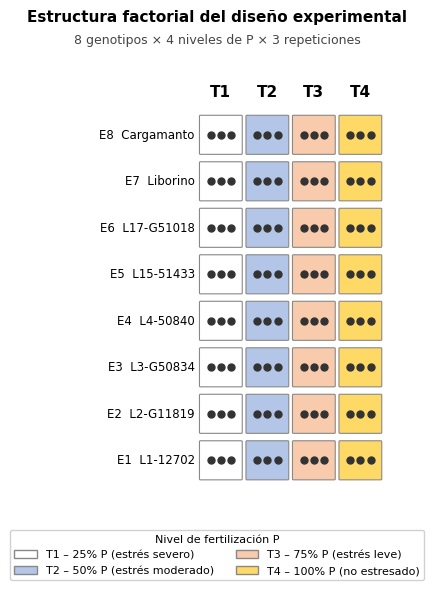

Figura B guardada.


In [35]:
OFFICIAL_ENTRIES = [1, 2, 3, 4, 5, 6, 7, 8]
P_LEVELS = [3, 2, 1, 0]
P_SHORT  = ["T1", "T2", "T3", "T4"]
N_REPS   = 3
N_ROWS   = len(OFFICIAL_ENTRIES)
N_COLS   = len(P_LEVELS)

fig_b = plt.figure(figsize=(7, 6))
ax2 = fig_b.add_axes([0.28, 0.18, 0.65, 0.62])
ax2.set_xlim(-0.5, N_COLS - 0.5)
ax2.set_ylim(-0.5, N_ROWS - 0.5)
ax2.set_aspect("equal")
ax2.axis("off")

for row_i, entry in enumerate(OFFICIAL_ENTRIES):
    for col_j, cls in enumerate(P_LEVELS):
        rect = mpatches.FancyBboxPatch(
            (col_j - 0.44, row_i - 0.40), 0.88, 0.80,
            boxstyle="round,pad=0.02",
            facecolor=CLASS_COLORS[cls],
            edgecolor="#888888", linewidth=0.8, zorder=2,
        )
        ax2.add_patch(rect)
        for r in range(N_REPS):
            ax2.plot(col_j - 0.22 + r * 0.22, row_i, "o",
                     color="#333333", markersize=5, zorder=3)

for row_i, entry in enumerate(OFFICIAL_ENTRIES):
    ax2.text(-0.56, row_i, f"E{entry}  {GENOTYPE_NAMES[entry]}",
             fontsize=8.5, ha="right", va="center")

for col_j, label in enumerate(P_SHORT):
    ax2.text(col_j, N_ROWS - 0.25, label,
             fontsize=11, ha="center", va="bottom", fontweight="bold")

fig_b.text(0.5, 0.97, "Estructura factorial del diseño experimental",
           fontsize=11, fontweight="bold", ha="center", va="top")
fig_b.text(0.5, 0.93, "8 genotipos × 4 niveles de P × 3 repeticiones",
           fontsize=9, ha="center", va="top", color="#444444")

legend_patches = [
    mpatches.Patch(facecolor=CLASS_COLORS[c], edgecolor="#888888", label=CLASS_LABELS[c])
    for c in [3, 2, 1, 0]
]
fig_b.legend(handles=legend_patches, loc="lower center", ncol=2,
             fontsize=8, title="Nivel de fertilización P", title_fontsize=8,
             framealpha=0.9, bbox_to_anchor=(0.5, 0.01))

fig_b.savefig(FIGS_PATH / "diagrama_factorial.png", dpi=200, bbox_inches="tight")
fig_b.savefig(FIGS_PATH / "diagrama_factorial.pdf", bbox_inches="tight")
plt.show()
print("Figura B guardada.")


## Nota metodológica — sobre la reconstrucción de la grilla 6×16

El campo `plot` (1–24) del GeoPackage identifica **unidades experimentales** (cada surco contiene plantas de los 4 niveles de P), no posiciones físicas únicas. Al calcular el centroide promedio por `plot`, todos convergen en un radio de ~8 m porque las plantas de cada surco están repartidas por todo el campo según el tratamiento de fósforo asignado.

La grilla 6×16 del Anexo 32 no se puede reconstruir automáticamente. En su lugar, la Figura A muestra la distribución real de los 335 polígonos, que revela la estructura espacial del experimento: los niveles de P se organizan en **bandas horizontales** (Sur→Norte: T4→T1), patrón coherente con un diseño en bloques completos al azar donde los bloques coinciden con gradientes de suelo.